In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

2026-06-07 11:21:58.597012: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780831318.880638      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780831318.966268      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780831319.637200      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780831319.637269      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780831319.637272      58 computation_placer.cc:177] computation placer alr

In [2]:
import os

for dirname, dirs, files in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/ryanbijujoseph
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data/unknown
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data/backward
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data/right
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data/left
/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data/forward


In [3]:
dataset_path = "/kaggle/input/datasets/ryanbijujoseph/hand-gesture-dataset/augmented_data"

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128,128),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128,128),
    batch_size=32
)

Found 13000 files belonging to 5 classes.
Using 10400 files for training.


2026-06-07 11:22:48.587791: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 13000 files belonging to 5 classes.
Using 2600 files for validation.


In [5]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [6]:
for images, labels in train_ds.take(1):
    print("Min:", images.numpy().min())
    print("Max:", images.numpy().max())

Min: 0.0
Max: 0.9992648


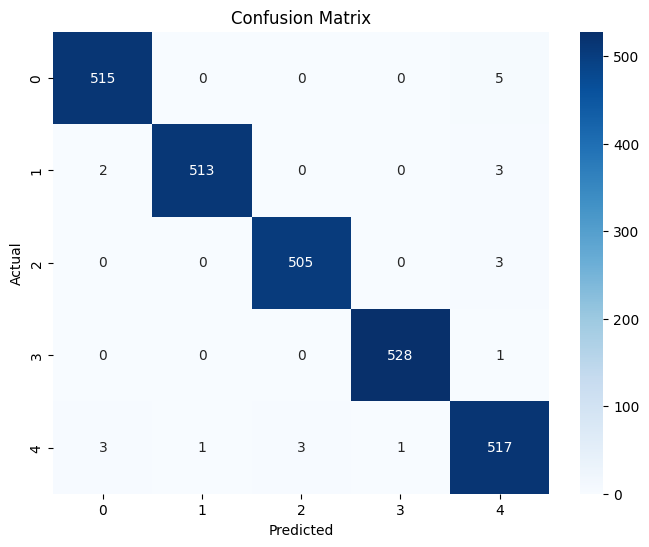

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Collect true labels and predictions
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [7]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu',
                           input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(5, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 190s 576ms/step - accuracy: 0.8530 - loss: 0.4078 - val_accuracy: 0.9723 - val_loss: 0.0877
Epoch 2/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 184s 566ms/step - accuracy: 0.9582 - loss: 0.1127 - val_accuracy: 0.9846 - val_loss: 0.0458
Epoch 3/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 182s 560ms/step - accuracy: 0.9751 - loss: 0.0719 - val_accuracy: 0.9854 - val_loss: 0.0487
Epoch 4/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 193s 592ms/step - accuracy: 0.9818 - loss: 0.0505 - val_accuracy: 0.9869 - val_loss: 0.0414
Epoch 5/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 185s 568ms/step - accuracy: 0.9856 - loss: 0.0402 - val_accuracy: 0.9892 - val_loss: 0.0448
Epoch 6/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 188s 579ms/step - accuracy: 0.9908 - loss: 0.0278 - val_accuracy: 0.9877 - val_loss: 0.0621
Epoch 7/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 182s 558ms/step - accuracy: 0.9914 - loss: 0.0239 - val_accuracy: 0.9904 - val_loss: 0.0335
Epoch 9/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 187s 575ms/step - accuracy: 0.9925 -

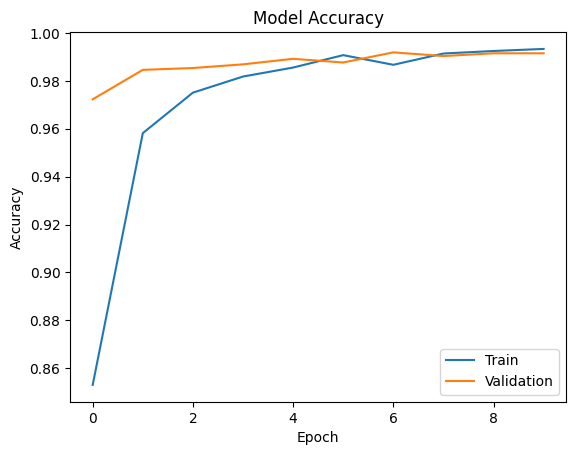

In [10]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()

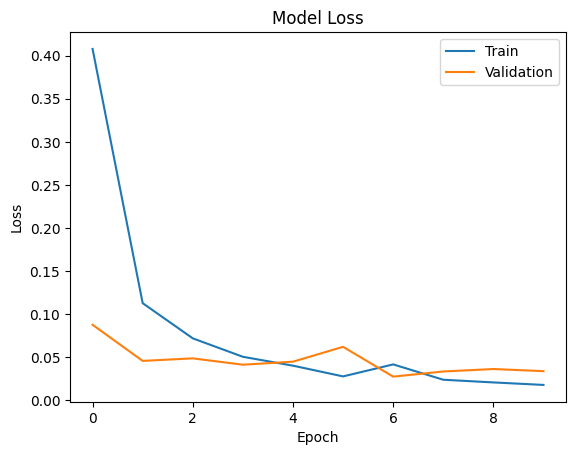

In [11]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()

In [13]:
model.save('hand_gesture_model.keras')

In [14]:
test_loss, test_accuracy = model.evaluate(val_ds)

print("Validation Accuracy:", test_accuracy)
print("Validation Loss:", test_loss)

82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 174ms/step - accuracy: 0.9915 - loss: 0.0339
Validation Accuracy: 0.9915384650230408
Validation Loss: 0.03386067599058151


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
Actual Class: 4
Predicted Class: 4


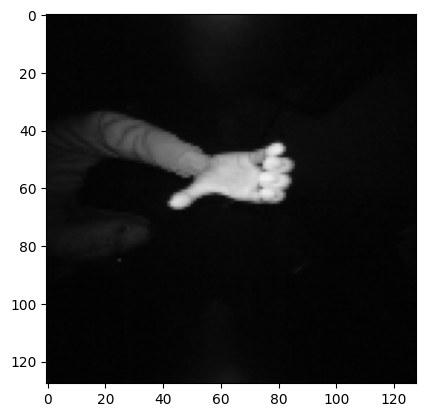

In [15]:
for images, labels in val_ds.take(1):
    sample_image = images[0]
    actual_label = labels[0]

prediction = model.predict(tf.expand_dims(sample_image, axis=0))

predicted_class = np.argmax(prediction)

print("Actual Class:", actual_label.numpy())
print("Predicted Class:", predicted_class)

plt.imshow(sample_image.numpy())
plt.show()

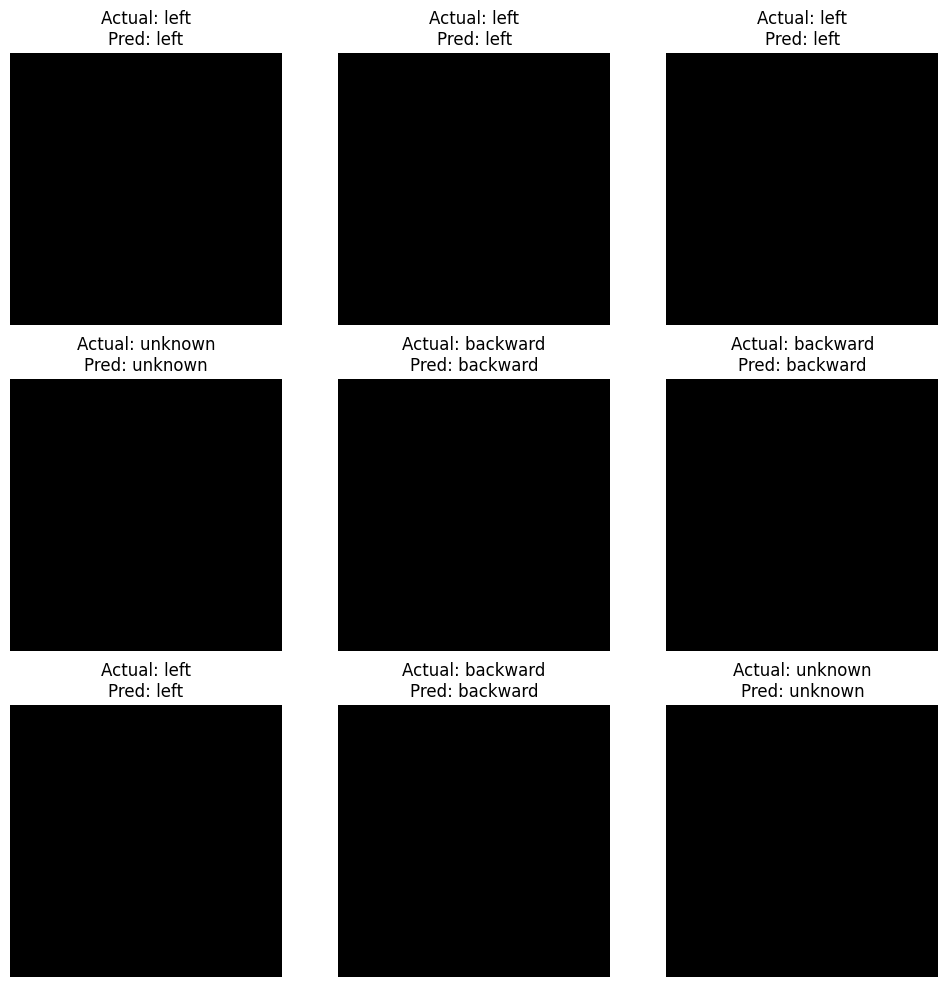

In [19]:
import matplotlib.pyplot as plt
import numpy as np

class_names = ['backward', 'forward', 'left', 'right', 'unknown']

for images, labels in val_ds.take(1):

    plt.figure(figsize=(12,12))

    for i in range(9):
        ax = plt.subplot(3,3,i+1)

        prediction = model.predict(
            tf.expand_dims(images[i], axis=0),
            verbose=0
        )

        pred_class = np.argmax(prediction)

        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(
            f"Actual: {class_names[labels[i]]}\nPred: {class_names[pred_class]}"
        )
        plt.axis("off")

    plt.show()

In [20]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=['backward','forward','left','right','unknown']
))

              precision    recall  f1-score   support

    backward       0.99      0.99      0.99       520
     forward       1.00      0.99      0.99       518
        left       0.99      0.99      0.99       508
       right       1.00      1.00      1.00       529
     unknown       0.98      0.98      0.98       525

    accuracy                           0.99      2600
   macro avg       0.99      0.99      0.99      2600
weighted avg       0.99      0.99      0.99      2600



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step


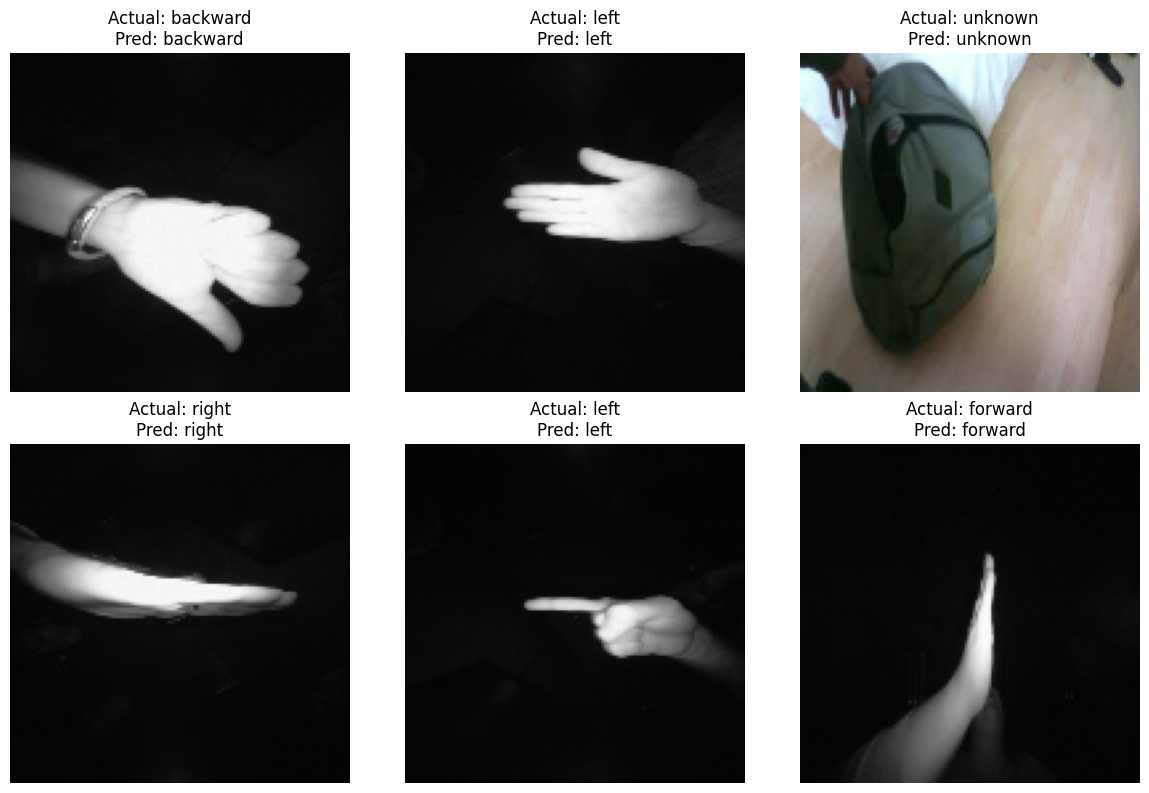

In [21]:
class_names = ['backward','forward','left','right','unknown']

plt.figure(figsize=(12,8))

for images, labels in val_ds.take(1):
    predictions = model.predict(images)

    for i in range(6):
        plt.subplot(2,3,i+1)

        plt.imshow(images[i].numpy().squeeze(), cmap='gray')

        actual = class_names[labels[i]]
        pred = class_names[np.argmax(predictions[i])]

        plt.title(f"Actual: {actual}\nPred: {pred}")
        plt.axis('off')

plt.tight_layout()
plt.show()